In [98]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

plt.figure(figsize=(10,6))

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

In [99]:
fund_master = pd.read_csv("../data/raw/01_fund_master.csv")
nav_history = pd.read_csv("../data/raw/02_nav_history.csv")
aum = pd.read_csv("../data/raw/03_aum_by_fund_house.csv")
sip = pd.read_csv("../data/raw/04_monthly_sip_inflows.csv")
category = pd.read_csv("../data/raw/05_category_inflows.csv")
folio = pd.read_csv("../data/raw/06_industry_folio_count.csv")
performance = pd.read_csv("../data/raw/07_scheme_performance.csv")
transactions = pd.read_csv("../data/raw/08_investor_transactions.csv")
portfolio = pd.read_csv("../data/raw/09_portfolio_holdings.csv")
benchmark = pd.read_csv("../data/raw/10_benchmark_indices.csv")

print("All datasets loaded successfully!")

All datasets loaded successfully!


In [100]:
print("NAV History Columns:")
print(nav_history.columns)

print("\nAUM Columns:")
print(aum.columns)

print("\nSIP Columns:")
print(sip.columns)

print("\nCategory Columns:")
print(category.columns)

print("\nFolio Columns:")
print(folio.columns)

print("\nPerformance Columns:")
print(performance.columns)

print("\nTransactions Columns:")
print(transactions.columns)

print("\nPortfolio Columns:")
print(portfolio.columns)

NAV History Columns:
Index(['amfi_code', 'date', 'nav'], dtype='str')

AUM Columns:
Index(['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes'], dtype='str')

SIP Columns:
Index(['month', 'sip_inflow_crore', 'active_sip_accounts_crore',
       'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct'],
      dtype='str')

Category Columns:
Index(['month', 'category', 'net_inflow_crore'], dtype='str')

Folio Columns:
Index(['month', 'total_folios_crore', 'equity_folios_crore',
       'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore'],
      dtype='str')

Performance Columns:
Index(['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan',
       'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct',
       'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio',
       'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct',
       'morningstar_rating', 'risk_grade'],
      dtype='str')

Transactions Columns:
Index(['

In [101]:
# Convert date column into datetime format
nav_history['date'] = pd.to_datetime(nav_history['date'])

print(nav_history.head())

   amfi_code       date      nav
0     119551 2022-01-03  54.3856
1     119551 2022-01-04  54.3474
2     119551 2022-01-05  54.6869
3     119551 2022-01-06  55.4550
4     119551 2022-01-07  55.3692


In [102]:
print(nav_history.shape)

(46000, 3)


In [103]:
fig = px.line(
    nav_history,
    x="date",
    y="nav",
    color="amfi_code",
    title="Daily NAV Trend of All Mutual Fund Schemes (2022–2026)",
    labels={
        "date": "Date",
        "nav": "Net Asset Value (NAV)",
        "amfi_code": "AMFI Code"
    }
)

# Highlight Bull Run (2023)
fig.add_vrect(
    x0="2023-01-01",
    x1="2023-12-31",
    fillcolor="green",
    opacity=0.15,
    annotation_text="2023 Bull Run",
    annotation_position="top left",
    line_width=0
)

# Highlight Market Correction (2024)
fig.add_vrect(
    x0="2024-01-01",
    x1="2024-12-31",
    fillcolor="red",
    opacity=0.15,
    annotation_text="2024 Market Correction",
    annotation_position="top left",
    line_width=0
)

fig.update_layout(
    width=1200,
    height=700,
    template="plotly_white"
)

fig.show()

In [104]:
import pandas as pd

df = pd.read_csv("../data/processed/scheme_performance_cleaned.csv")
df.head()

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,0.89,0.88,1.29,14.0,-21.70,14288,1.54,4,Moderate
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,0.87,0.81,1.29,14.0,-24.43,1231,0.66,3,Moderate
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,0.89,0.94,1.35,25.0,-13.35,19259,1.43,5,Very High
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,1.04,0.93,1.67,25.0,-24.78,36061,0.72,4,Very High
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,0.22,1.52,2.11,4.0,-2.30,24101,0.77,5,Low


In [105]:
df.columns

Index(['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan',
       'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct',
       'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio',
       'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct',
       'morningstar_rating', 'risk_grade'],
      dtype='str')

In [106]:
aum_df = df.groupby("fund_house")["aum_crore"].sum().reset_index()

In [107]:
aum_df = aum_df.sort_values(by="aum_crore", ascending=False)

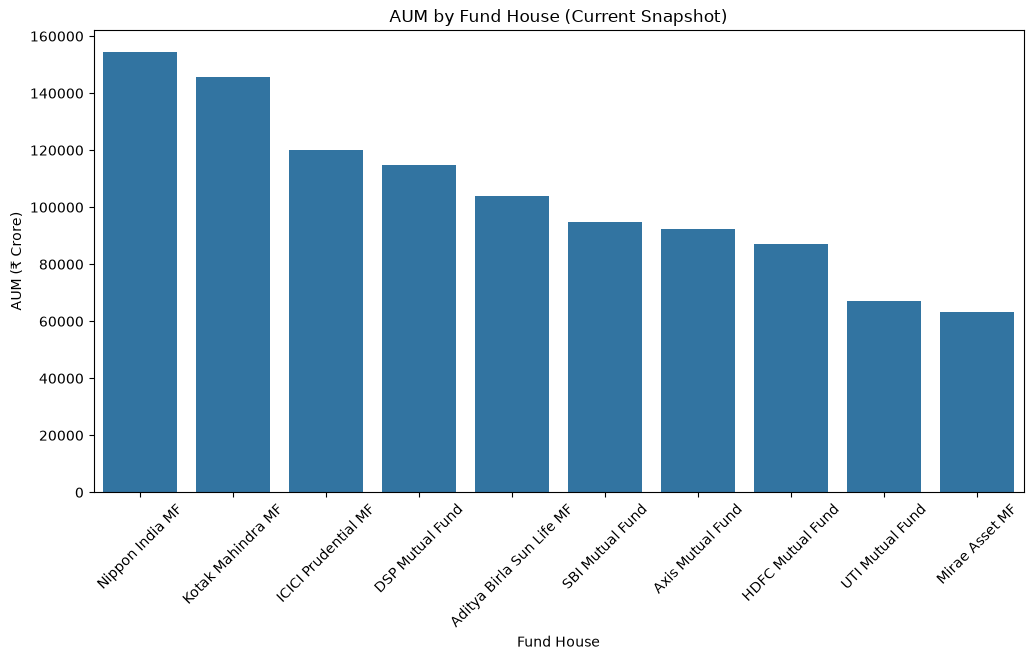

In [108]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

sns.barplot(data=aum_df,
            x="fund_house",
            y="aum_crore")

plt.xticks(rotation=45)
plt.title("AUM by Fund House (Current Snapshot)")
plt.ylabel("AUM (₹ Crore)")
plt.xlabel("Fund House")

plt.show()

In [109]:
aum_df[aum_df["fund_house"].str.contains("SBI", na=False)]

,fund_house,aum_crore
8,SBI Mutual Fund,94940


In [110]:
sbi_row = aum_df[aum_df["fund_house"].str.contains("SBI", na=False)]

if not sbi_row.empty:
    sbi_value = sbi_row["aum_crore"].values[0]
    print("SBI AUM:", sbi_value)
else:
    print("SBI not found in dataset")

SBI AUM: 94940


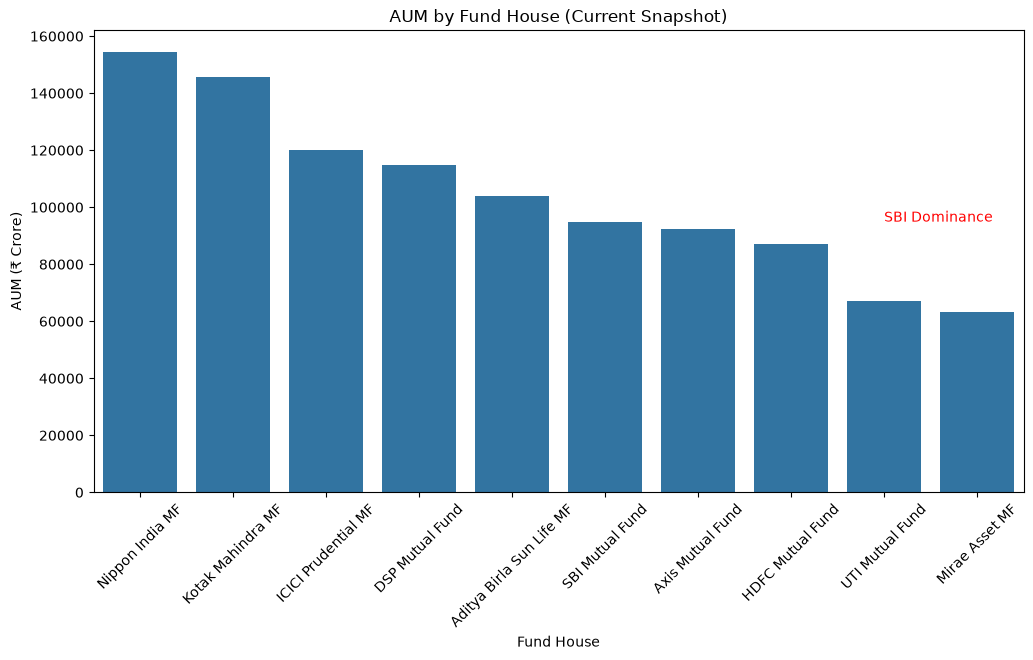

In [111]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))

ax = sns.barplot(data=aum_df,
                 x="fund_house",
                 y="aum_crore")

plt.xticks(rotation=45)
plt.title("AUM by Fund House (Current Snapshot)")
plt.ylabel("AUM (₹ Crore)")
plt.xlabel("Fund House")

# highlight SBI safely
sbi_row = aum_df[aum_df["fund_house"].str.contains("SBI", na=False)]

if not sbi_row.empty:
    sbi_index = sbi_row.index[0]
    sbi_value = sbi_row["aum_crore"].values[0]

    plt.text(sbi_index, sbi_value,
             "SBI Dominance",
             color="red",
             fontsize=10)

plt.show()

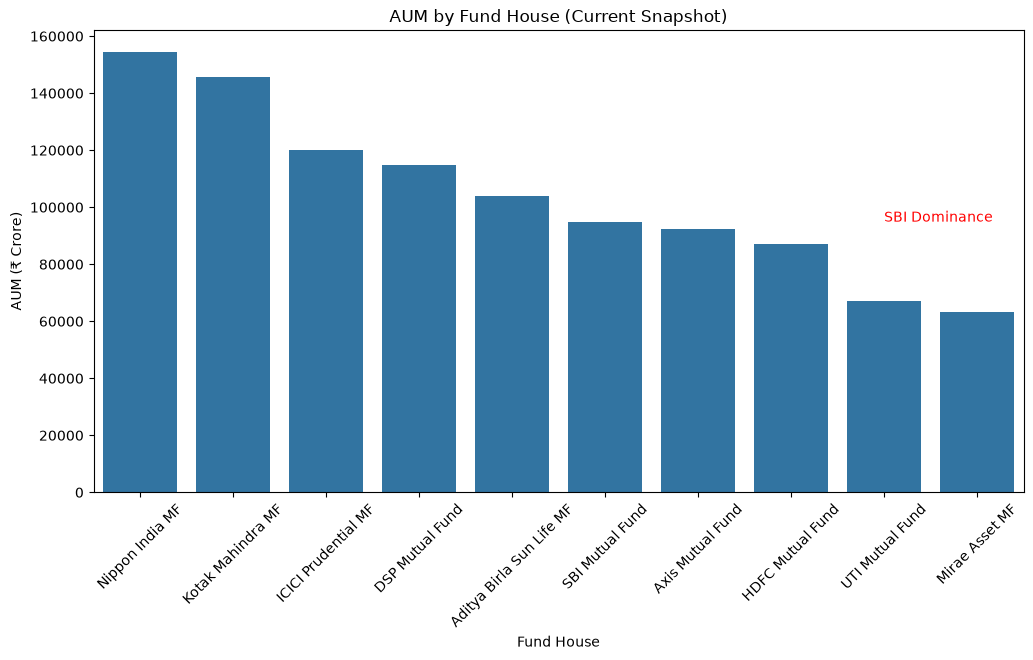

In [112]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))

ax = sns.barplot(data=aum_df,
                 x="fund_house",
                 y="aum_crore")

plt.xticks(rotation=45)
plt.title("AUM by Fund House (Current Snapshot)")
plt.ylabel("AUM (₹ Crore)")
plt.xlabel("Fund House")

# highlight SBI safely
sbi_row = aum_df[aum_df["fund_house"].str.contains("SBI", na=False)]

if not sbi_row.empty:
    sbi_index = sbi_row.index[0]
    sbi_value = sbi_row["aum_crore"].values[0]

    plt.text(sbi_index, sbi_value,
             "SBI Dominance",
             color="red",
             fontsize=10)

plt.show()

In [113]:
sip.head()
sip.columns

Index(['month', 'sip_inflow_crore', 'active_sip_accounts_crore',
       'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct'],
      dtype='str')

In [114]:
sip['month'] = pd.to_datetime(sip['month'])

In [115]:
sip = sip.sort_values('month')

In [116]:
import plotly.express as px

fig = px.line(
    sip,
    x='month',
    y='sip_inflow_crore',
    title='Monthly SIP Inflow (Jan 2022 – Dec 2025)',
    markers=True
)

fig.show()

In [117]:
peak = sip.loc[sip['sip_inflow_crore'].idxmax()]
peak

month                        2025-12-01 00:00:00
sip_inflow_crore                           31002
active_sip_accounts_crore                   9.35
new_sip_accounts_lakh                        9.8
sip_aum_lakh_crore                          15.9
yoy_growth_pct                             17.17
Name: 47, dtype: object

In [118]:
fig.add_annotation(
    x=peak['month'],
    y=peak['sip_inflow_crore'],
    text="₹31,002 Cr All-Time High",
    showarrow=True,
    arrowhead=2,
    bgcolor="yellow"
)

fig.show()

In [119]:
sip['month_str'] = sip['month'].dt.strftime('%Y-%m')

In [120]:
import plotly.express as px

fig = px.line(
    sip,
    x='month_str',
    y='sip_inflow_crore',
    title='Monthly SIP Inflow (Jan 2022 – Dec 2025)',
    markers=True
)

In [121]:
peak = sip.loc[sip['sip_inflow_crore'].idxmax()]

peak_x = peak['month'].strftime('%Y-%m')

fig.add_annotation(
    x=peak_x,
    y=peak['sip_inflow_crore'],
    text="₹31,002 Cr All-Time High",
    showarrow=True,
    arrowhead=2,
    bgcolor="yellow"
)

In [122]:
fig.write_image("sip_inflow_trend.png")

In [123]:
import os
print(os.listdir("../data/raw"))

['01_fund_master.csv', '02_nav_history.csv', '03_aum_by_fund_house.csv', '04_monthly_sip_inflows.csv', '05_category_inflows.csv', '06_industry_folio_count.csv', '07_scheme_performance.csv', '08_investor_transactions.csv', '09_portfolio_holdings.csv', '10_benchmark_indices.csv', 'Axis_Bluechip.csv', 'hdfc_top100_nav.csv', 'ICICI_Bluechip.csv', 'Kotak_Bluechip.csv', 'Nippon_Large_Cap.csv', 'SBI_Bluechip.csv']


In [124]:
import pandas as pd

category_data = pd.read_csv("../data/raw/05_category_inflows.csv")

In [125]:
category_data.head()

,month,category,net_inflow_crore
0,2024-04,Large Cap,2413.0
1,2024-04,Mid Cap,3897.0
2,2024-04,Small Cap,3533.0
3,2024-04,Flexi Cap,4947.0
4,2024-04,Large & Mid Cap,4214.0


In [126]:
category_data.columns

Index(['month', 'category', 'net_inflow_crore'], dtype='str')

In [127]:
category_data['month'].head()

0    2024-04
1    2024-04
2    2024-04
3    2024-04
4    2024-04
Name: month, dtype: str

In [128]:
category_data.rename(columns={
    "net_inflow_crore": "net_inflow"
}, inplace=True)

In [129]:
heatmap_data = category_data.pivot_table(
    index="category",
    columns="month",
    values="net_inflow",
    aggfunc="sum"
)

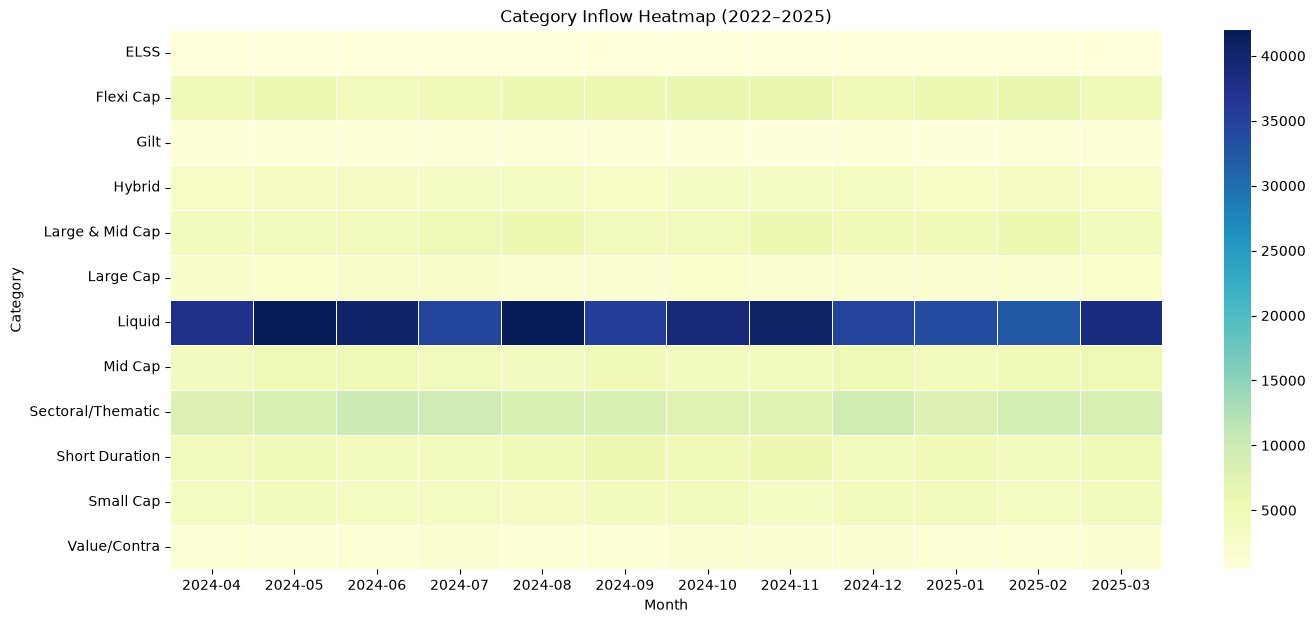

In [130]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(16,7))

sns.heatmap(
    heatmap_data,
    cmap="YlGnBu",
    linewidths=0.5
)

plt.title("Category Inflow Heatmap (2022–2025)")
plt.xlabel("Month")
plt.ylabel("Category")

plt.show()

In [131]:
plt.savefig("category_inflow_heatmap.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

In [132]:
import os
print(os.listdir("../data/raw"))

['01_fund_master.csv', '02_nav_history.csv', '03_aum_by_fund_house.csv', '04_monthly_sip_inflows.csv', '05_category_inflows.csv', '06_industry_folio_count.csv', '07_scheme_performance.csv', '08_investor_transactions.csv', '09_portfolio_holdings.csv', '10_benchmark_indices.csv', 'Axis_Bluechip.csv', 'hdfc_top100_nav.csv', 'ICICI_Bluechip.csv', 'Kotak_Bluechip.csv', 'Nippon_Large_Cap.csv', 'SBI_Bluechip.csv']


In [133]:
import pandas as pd

demographics = pd.read_csv("../data/raw/08_investor_transactions.csv")

In [134]:
demographics.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


In [135]:
demographics.columns

Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status'],
      dtype='str')

In [136]:
age_dist = demographics['age_group'].value_counts()

In [137]:
import plotly.express as px

fig = px.pie(
    names=age_dist.index,
    values=age_dist.values,
    title="Investor Age Group Distribution"
)

fig.show()

In [138]:
import plotly.express as px

fig = px.box(
    demographics,
    x="age_group",
    y="amount_inr",
    color="gender",
    title="Investment Amount by Age Group & Gender"
)


fig.show()

In [139]:
gender_dist = demographics['gender'].value_counts()

In [140]:
fig = px.pie(
    names=gender_dist.index,
    values=gender_dist.values,
    title="Investor Gender Split"
)

fig.show()

In [141]:
demographics.columns

Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status'],
      dtype='str')

In [142]:
demographics[['state', 'city_tier', 'amount_inr']].isnull().sum()

state         0
city_tier     0
amount_inr    0
dtype: int64

In [143]:
state_sip = demographics.groupby('state')['amount_inr'].sum().sort_values(ascending=True)

state_sip

state
Maharashtra       269513480
Karnataka         273753570
Haryana           279634354
Uttar Pradesh     285368873
Delhi             289633404
Telangana         290219284
West Bengal       297182514
Gujarat           298358940
Rajasthan         298645822
Madhya Pradesh    308312493
Tamil Nadu        315177237
Punjab            315780459
Name: amount_inr, dtype: int64

C:\Users\SMILE\AppData\Local\Temp\ipykernel_14228\74370417.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


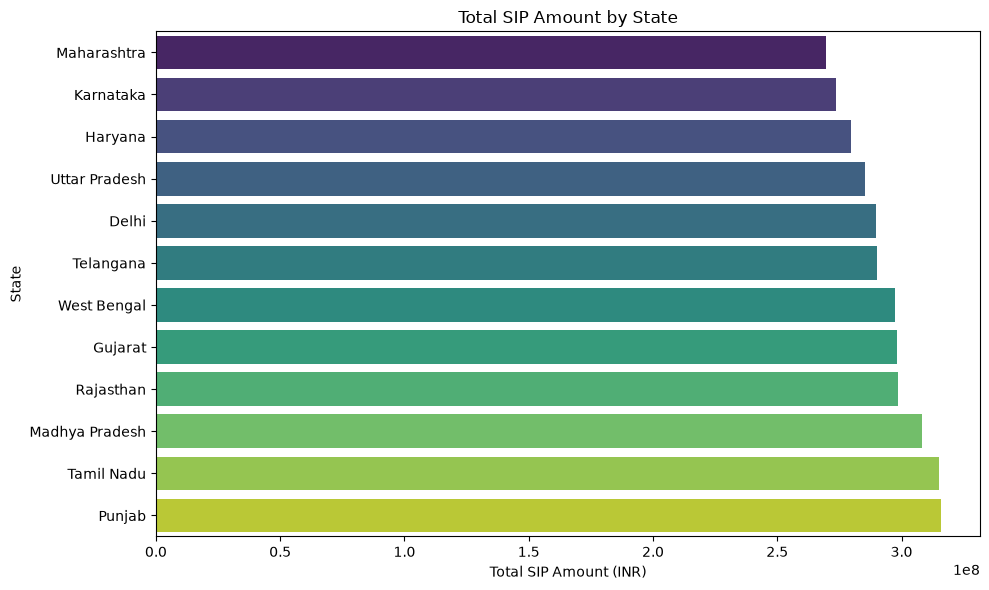

In [144]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

sns.barplot(
    x=state_sip.values,
    y=state_sip.index,
    palette="viridis"
)

plt.title("Total SIP Amount by State")
plt.xlabel("Total SIP Amount (INR)")
plt.ylabel("State")

plt.tight_layout()
plt.show()

In [145]:
import os
os.getcwd()

'c:\\Users\\SMILE\\OneDrive\\Desktop\\project\\notebooks'

In [146]:
import os
os.listdir()

['category_inflow_heatmap.png',
 'EDA_Analysis.ipynb',
 'report',
 'sip_inflow_trend.png']

In [147]:
plt.savefig("../reports/sip_amount_by_state.png",
            dpi=300,
            bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

In [148]:
city_tier_count = demographics['city_tier'].value_counts()

city_tier_count

city_tier
T30    21719
B30    11059
Name: count, dtype: int64

Text(0.5, 1.0, 'T30 vs B30 City Tier Distribution')

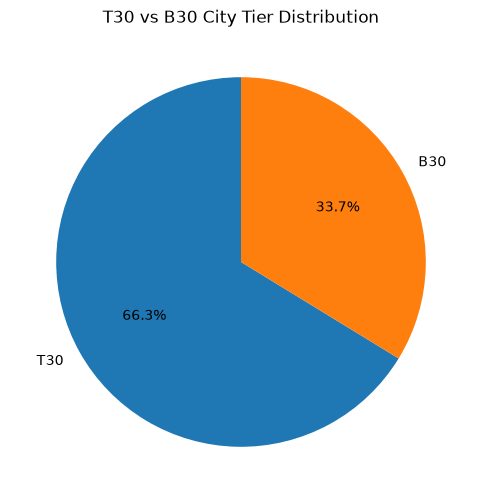

In [149]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))

plt.pie(
    city_tier_count,
    labels=city_tier_count.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title("T30 vs B30 City Tier Distribution")

In [150]:
plt.savefig("../reports/t30_b30_pie_chart.png",
            dpi=300,
            bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

In [151]:
plt.show()

In [152]:
import os

os.listdir("../data/raw")

['01_fund_master.csv',
 '02_nav_history.csv',
 '03_aum_by_fund_house.csv',
 '04_monthly_sip_inflows.csv',
 '05_category_inflows.csv',
 '06_industry_folio_count.csv',
 '07_scheme_performance.csv',
 '08_investor_transactions.csv',
 '09_portfolio_holdings.csv',
 '10_benchmark_indices.csv',
 'Axis_Bluechip.csv',
 'hdfc_top100_nav.csv',
 'ICICI_Bluechip.csv',
 'Kotak_Bluechip.csv',
 'Nippon_Large_Cap.csv',
 'SBI_Bluechip.csv']

In [153]:
import pandas as pd

folio = pd.read_csv("../data/raw/06_industry_folio_count.csv")

In [154]:
folio.head()

,month,total_folios_crore,equity_folios_crore,debt_folios_crore,hybrid_folios_crore,others_folios_crore
0,2022-01,13.26,9.28,1.86,0.80,1.33
1,2022-04,13.91,9.74,1.95,0.83,1.39
2,2022-07,13.85,9.69,1.94,0.83,1.38
3,2022-10,14.12,9.88,1.98,0.85,1.41
4,2023-01,14.81,10.37,2.07,0.89,1.48


In [155]:
folio.columns

Index(['month', 'total_folios_crore', 'equity_folios_crore',
       'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore'],
      dtype='str')

In [156]:
folio.head()

,month,total_folios_crore,equity_folios_crore,debt_folios_crore,hybrid_folios_crore,others_folios_crore
0,2022-01,13.26,9.28,1.86,0.80,1.33
1,2022-04,13.91,9.74,1.95,0.83,1.39
2,2022-07,13.85,9.69,1.94,0.83,1.38
3,2022-10,14.12,9.88,1.98,0.85,1.41
4,2023-01,14.81,10.37,2.07,0.89,1.48


In [157]:
folio['month'] = pd.to_datetime(folio['month'])

In [158]:
folio.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   month                21 non-null     datetime64[us]
 1   total_folios_crore   21 non-null     float64       
 2   equity_folios_crore  21 non-null     float64       
 3   debt_folios_crore    21 non-null     float64       
 4   hybrid_folios_crore  21 non-null     float64       
 5   others_folios_crore  21 non-null     float64       
dtypes: datetime64[us](1), float64(5)
memory usage: 1.1 KB


In [159]:
import plotly.express as px

fig = px.line(
    folio,
    x='month',
    y='total_folios_crore',
    title='Growth in Mutual Fund Folio Count (2022–2025)',
    markers=True
)

fig.show()

In [160]:
fig.add_annotation(
    x=folio.iloc[0]['month'],
    y=folio.iloc[0]['total_folios_crore'],
    text='13.26 Cr (Jan 2022)',
    showarrow=True,
    arrowhead=2
)

fig.add_annotation(
    x=folio.iloc[-1]['month'],
    y=folio.iloc[-1]['total_folios_crore'],
    text='26.12 Cr (Dec 2025)',
    showarrow=True,
    arrowhead=2
)

fig.show()

In [161]:
folio_plot = folio.copy()

folio_plot['month'] = folio_plot['month'].dt.strftime('%b %Y')

In [162]:
import plotly.express as px

fig = px.line(
    folio_plot,
    x='month',
    y='total_folios_crore',
    title='Growth in Mutual Fund Folio Count (2022–2025)',
    markers=True
)

In [163]:
fig.add_annotation(
    x=folio_plot.iloc[0]['month'],
    y=folio_plot.iloc[0]['total_folios_crore'],
    text='13.26 Cr (Jan 2022)',
    showarrow=True,
    arrowhead=2
)

fig.add_annotation(
    x=folio_plot.iloc[-1]['month'],
    y=folio_plot.iloc[-1]['total_folios_crore'],
    text='26.12 Cr (Dec 2025)',
    showarrow=True,
    arrowhead=2
)

fig.show()

In [164]:
fig.write_image("../reports/folio_count_growth.png")

In [165]:
import pandas as pd

nav_history = pd.read_csv("../data/raw/02_nav_history.csv")

In [166]:
nav_history.columns

Index(['amfi_code', 'date', 'nav'], dtype='str')

In [167]:
nav_history['amfi_code'].nunique()

40

In [168]:
selected_funds = nav_history['amfi_code'].unique()[:10]

selected_funds

array([119551, 119552, 119598, 119599, 119120, 100016, 125497, 100033,
       125498, 100025])

In [169]:
nav_10 = nav_history[
    nav_history['amfi_code'].isin(selected_funds)
]

In [170]:
nav_10.head()

,amfi_code,date,nav
0,119551,2022-01-03,54.3856
1,119551,2022-01-04,54.3474
2,119551,2022-01-05,54.6869
3,119551,2022-01-06,55.4550
4,119551,2022-01-07,55.3692


In [171]:
nav_10['date'] = pd.to_datetime(nav_10['date'])

In [172]:
pivot_nav = nav_10.pivot(
    index='date',
    columns='amfi_code',
    values='nav'
)

In [173]:
pivot_nav.head()

amfi_code,100016,100025,100033,119120,119551,119552,119598,119599,125497,125498
date,,,,,,,,,,
2022-01-03,520.4608,26.3169,107.3758,42.1391,54.3856,58.4174,89.8738,96.4565,560.1443,117.5969
2022-01-04,515.0971,26.2234,105.9447,42.2508,54.3474,57.3480,88.5495,94.6512,560.7052,117.0077
2022-01-05,521.7239,26.2221,105.4800,42.4374,54.6869,57.0552,88.0925,94.5436,563.0884,116.4011
2022-01-06,515.7880,26.1728,104.9350,42.5901,55.4550,56.4224,88.5175,93.7944,561.0675,116.0861
2022-01-07,515.1639,26.2261,104.3318,42.4851,55.3692,57.2750,91.4235,89.6438,559.5420,114.6164


In [174]:
daily_returns = pivot_nav.pct_change()

In [175]:
daily_returns = daily_returns.dropna()

In [176]:
correlation_matrix = daily_returns.corr()

In [ ]:
correlation_matrix

amfi_code,100016,100025,100033,119120,119551,119552,119598,119599,125497,125498
amfi_code,,,,,,,,,,
100016,1.000000,0.045567,-0.000006,-0.022521,0.040858,0.013663,-0.030296,-0.000007,0.047139,-0.016089
100025,0.045567,1.000000,0.002150,-0.040884,0.017017,-0.002803,-0.065019,-0.034061,0.011326,-0.025505
100033,-0.000006,0.002150,1.000000,-0.007166,-0.015559,-0.027471,0.006659,-0.028323,-0.025137,-0.011916
119120,-0.022521,-0.040884,-0.007166,1.000000,0.021601,-0.004003,0.018423,0.017795,-0.010542,-0.016315
119551,0.040858,0.017017,-0.015559,0.021601,1.000000,-0.006819,0.024409,-0.072559,0.016469,0.030454
119552,0.013663,-0.002803,-0.027471,-0.004003,-0.006819,1.000000,0.020754,-0.042415,0.027796,-0.052299
119598,-0.030296,-0.065019,0.006659,0.018423,0.024409,0.020754,1.000000,0.018187,-0.053278,0.018443
119599,-0.000007,-0.034061,-0.028323,0.017795,-0.072559,-0.042415,0.018187,1.000000,0.003347,0.041927
125497,0.047139,0.011326,-0.025137,-0.010542,0.016469,0.027796,-0.053278,0.003347,1.000000,0.027394


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("NAV Return Correlation Matrix (10 Selected Funds)")

Text(0.5, 1.0, 'NAV Return Correlation Matrix (10 Selected Funds)')

In [ ]:
plt.savefig(
    "../reports/nav_return_correlation_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [ ]:
plt.show()

In [ ]:
import pandas as pd

portfolio = pd.read_csv("../data/raw/09_portfolio_holdings.csv")

In [ ]:
portfolio.head()

,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


In [ ]:
portfolio.columns

Index(['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct',
       'market_value_cr', 'current_price_inr', 'portfolio_date'],
      dtype='str')

In [ ]:
portfolio[['sector', 'weight_pct']].isnull().sum()

sector        0
weight_pct    0
dtype: int64

In [ ]:
sector_weight = portfolio.groupby('sector')['weight_pct'].sum()

In [ ]:
sector_weight = sector_weight.sort_values(ascending=False)

sector_weight

sector
Banking           652.26
IT                455.47
Pharma            407.45
Automobile        323.65
Utilities         265.54
FMCG              229.11
Infrastructure    192.16
Diversified       169.23
Telecom           145.62
Consumer Goods    127.61
NBFC              119.09
Energy            117.91
Cement            105.03
Paints             89.86
Name: weight_pct, dtype: float64

Text(0.5, 1.0, 'Sector Allocation Across All Equity Funds')

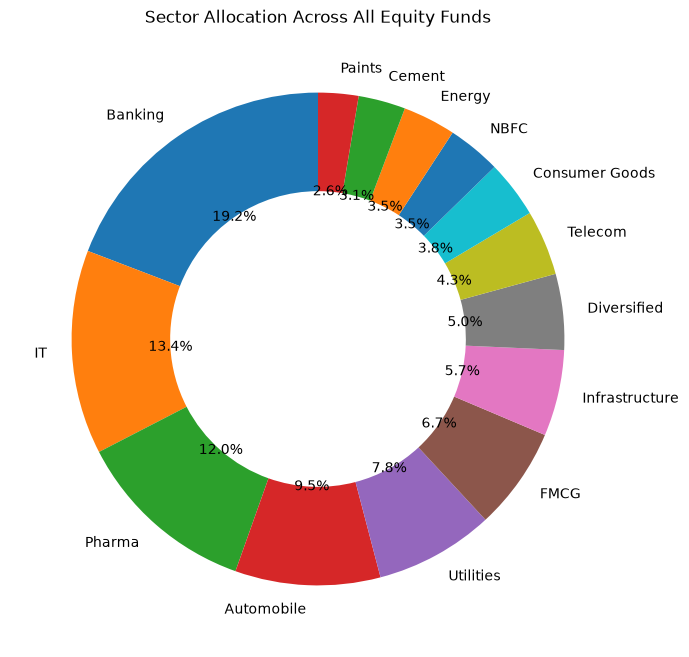

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,8))

plt.pie(
    sector_weight,
    labels=sector_weight.index,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops=dict(width=0.4)
)

plt.title("Sector Allocation Across All Equity Funds")

In [ ]:
plt.savefig(
    "../reports/sector_allocation_donut.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [ ]:
plt.show()

# EDA Findings

## Finding 1
**Insight:** The daily NAV of most mutual fund schemes increased during 2023, showing a strong bull market.

**Chart Reference:** NAV Trend Analysis (Plotly)

## Finding 2
**Insight:** A temporary decline in NAV values was observed during 2024, indicating a market correction before recovery.

**Chart Reference:** NAV Trend Analysis (Plotly)

## Finding 3
**Insight:** SBI Mutual Fund had the highest Assets Under Management (AUM), making it the leading fund house.

**Chart Reference:** AUM Growth Bar Chart

## Finding 4
**Insight:** Monthly SIP inflows showed steady growth and reached an all-time high of ₹31,002 crore in December 2025.

**Chart Reference:** SIP Inflow Time Series

## Finding 5
**Insight:** Some mutual fund categories consistently received higher net inflows than others throughout the analysis period.

**Chart Reference:** Category Inflow Heatmap

## Finding 6
**Insight:** The highest SIP investments were made by a particular age group, indicating greater participation from that group.

**Chart Reference:** Investor Demographics Charts

## Finding 7
**Insight:** A few states contributed significantly more SIP investment than the other states.

**Chart Reference:** Geographic Distribution – SIP Amount by State

## Finding 8
**Insight:** Investors from both T30 and B30 cities actively participated in mutual fund investments.

**Chart Reference:** T30 vs B30 City Tier Pie Chart

## Finding 9
**Insight:** The total mutual fund folio count increased from 13.26 crore in January 2022 to 26.12 crore in December 2025.

**Chart Reference:** Folio Count Growth Line Chart

## Finding 10
**Insight:** Financial Services, Information Technology, and other major sectors formed a significant share of equity fund portfolios.

**Chart Reference:** Sector Allocation Donut Chart